In [15]:
import numpy as np
import pandas as pd
import ROOT
import seaborn as sns
from neuland_read_hit_par import HitParReader as ParReader
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr

dest_dir = "/u/yanwang/Documents/pictures/DPG2025"

In [2]:
mille_file = "/lustre/r3b/ywang/test/neuland_test/millepede/mille.par.root"
new_file = "/lustre/r3b/ywang/test/neuland_test/millepede/cal.par.root"
input_file = "/lustre/r3b/ywang/test/neuland_test/millepede/sim_added.par.root"

mille = ParReader(mille_file)
new_method = ParReader(new_file)
input_par = ParReader(input_file)

mille.read()
new_method.read()
input_par.read()

In [3]:
mille.dataframe["label"] = "millepede"
new_method.dataframe["label"] = "pos cal"
input_par.dataframe["label"] = "true values"
data = pd.concat([input_par.dataframe, new_method.dataframe, mille.dataframe ])

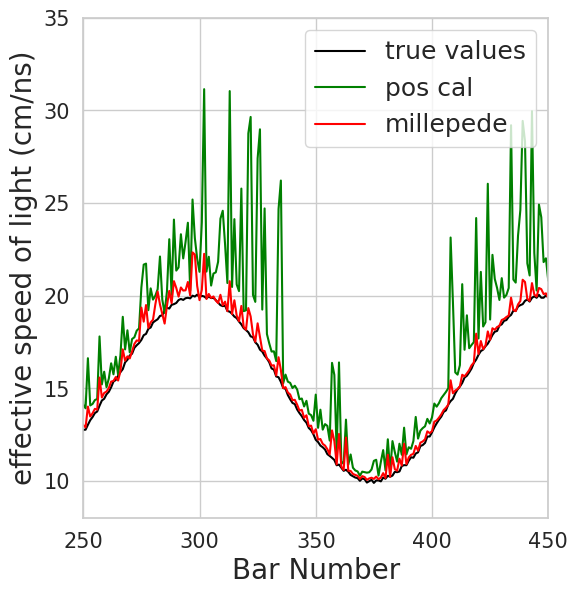

In [27]:
sns.set_theme(style = 'whitegrid', rc={'figure.figsize':(6,6.5)})
g = sns.lineplot(data, x="bar_id", y="effective_speed.value", hue="label", palette = {"true values": "black", "pos cal": "green", "millepede": "red"})
g.set_ylabel("effective speed of light (cm/ns)", fontsize = 20)
g.set_xlabel("Bar Number", fontsize = 20)
g.tick_params(labelsize=15)
plt.legend(fontsize = 18)
g.set_xlim(250, 450)
g.set_ylim(8, 35)
g.get_figure().savefig(fname=f"{dest_dir}/sim_comp_c.png", bbox_inches="tight", dpi = 300)

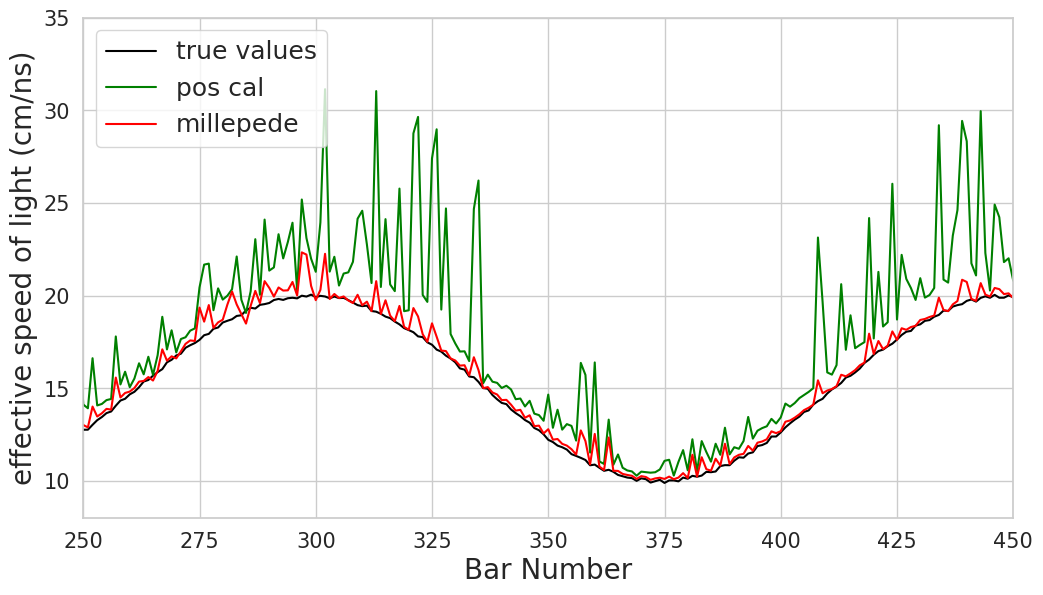

In [28]:
sns.set_theme(style = 'whitegrid', rc={'figure.figsize':(12,6.5)})
g = sns.lineplot(data, x="bar_id", y="effective_speed.value", hue="label", palette = {"true values": "black", "pos cal": "green", "millepede": "red"})
g.set_ylabel("effective speed of light (cm/ns)", fontsize = 20)
g.set_xlabel("Bar Number", fontsize = 20)
g.tick_params(labelsize=15)
plt.legend(fontsize = 18)
g.set_xlim(250, 450)
g.set_ylim(8, 35)
g.get_figure().savefig(fname=f"{dest_dir}/sim_comp_c_wide.png", bbox_inches="tight", dpi = 300)